# Handling Missing Values
Handling missing values in machine learning means `fixing or removing incomplete data entries`—such as NaN, None, or blank spaces—so algorithms can train properly  

---
### Types of Missing Data
* **MCAR (Missing Completely at Random):** Data is missing by pure chance, with no connection to any values.
* **MAR (Missing at Random):** Missing data relates to other known variables in the set, but not to the missing value itself.
* **MNAR (Missing Not at Random):** The missing value has a direct reason related to its own missing data (e.g., high earners hiding salary)

---
### Main Methods to Handle Missing Values
* **Deletion (Omission):** Remove rows or columns with missing data. This works best for MCAR with large datasets, but it causes data loss and bias if used poorly.
* **Simple Imputation:** Fill empty spots using basic stats like the mean, median, or mode from the same column
* **Advanced Imputation:** Use predictive models or algorithms like `k-NN Imputer` (k-nearest neighbors) to guess values based on similar data points
* **Sequence Filling:** Use `forward fill` or `backward fill` to copy adjacent values, which is useful for time-series data
---

## Complete Case Analysis - CCA
**Complete Case Analysis (CCA)**, also known as **listwise deletion**, is a data-cleaning method where you completely remove any row (case) that has at least one missing value. You train your machine learning model only on the "complete cases."

---
### When to Use CCA
* **Large Datasets:** The data loss does not heavily impact your sample size
* **Minimal Missingness:** Less than **5% of the data** is missing across the entire dataset
* **MCAR Data:** The data is missing completely at random, meaning the missing values are a random subset of the data
---
### The Advantages and Disadvantages of CCA
| **Advantage** | **Disadvantage** |
|---|---|
| Simple to implement with a single line of code. | Can cause severe data loss if missing values are spread across many rows. |
| Introduces no artificial noise or fake data points. | Introduces heavy bias if the data is not Missing Completely at Random (MCAR). |
| Preserves the natural relationship between features. | Reduces statistical power because it shrinks your sample size. |

---

### The Mathematical Catch: Why MCAR Matters
If your data is `MCAR`, deleting rows simply reduces your sample size but keeps the dataset representative of the population.  
   
However, if your data is `MAR` or `MNAR`, CCA breaks your model. For example, if lower-income individuals choose not to report their income, deleting those rows removes a specific demographic. Your model will then train on an unrepresentative, higher-income dataset, skewing all future predictions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [6]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
4325,0.691,no_enrollment,Graduate,9.0,31.0
1996,0.624,Part time course,Graduate,2.0,77.0
586,0.893,no_enrollment,Masters,12.0,107.0
1743,0.910,no_enrollment,Masters,15.0,20.0
6340,0.926,no_enrollment,Masters,20.0,13.0


In [8]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [9]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [10]:
new_df = df[cols].dropna()
new_df.shape, df.shape

((17182, 5), (19158, 13))

In [11]:
new_df.columns

Index(['city_development_index', 'enrolled_university', 'education_level',
       'experience', 'training_hours'],
      dtype='object')

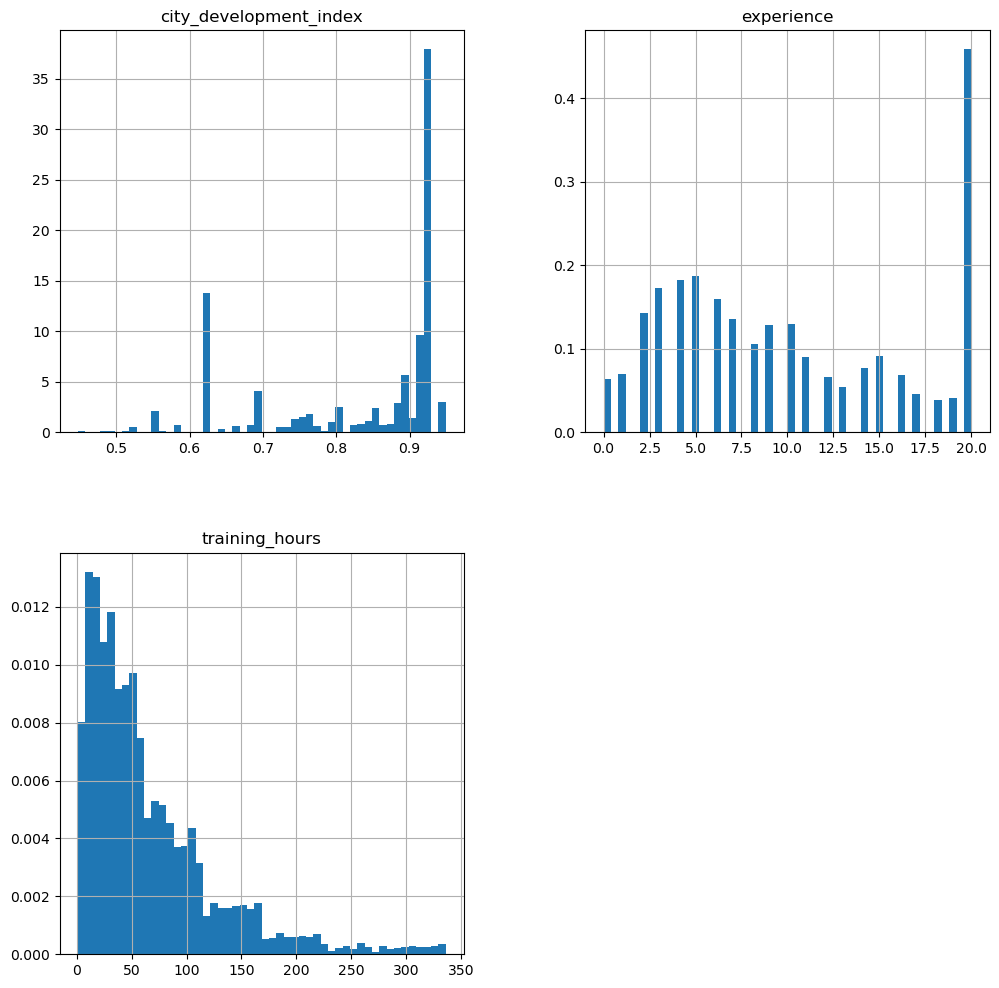

In [12]:
new_df.hist(bins = 50, density=True, figsize=(12, 12))
plt.show()

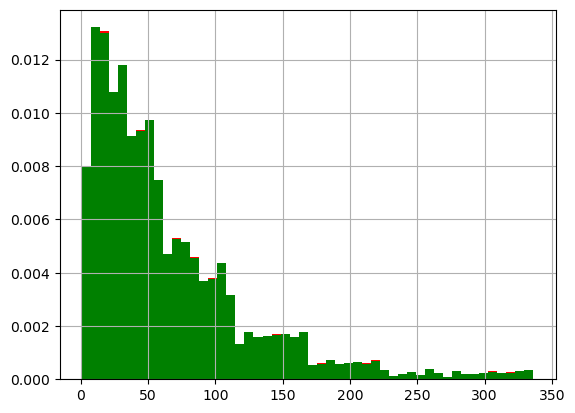

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# Data after cca, the argument alpha makes the color transparent, so that we can see the overlay of the 2 distribution
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green')

plt.show()

<Axes: >

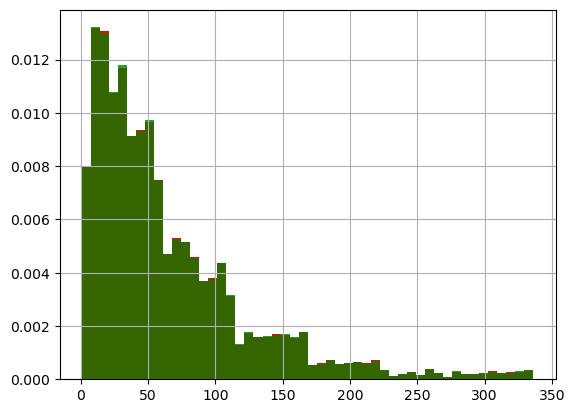

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

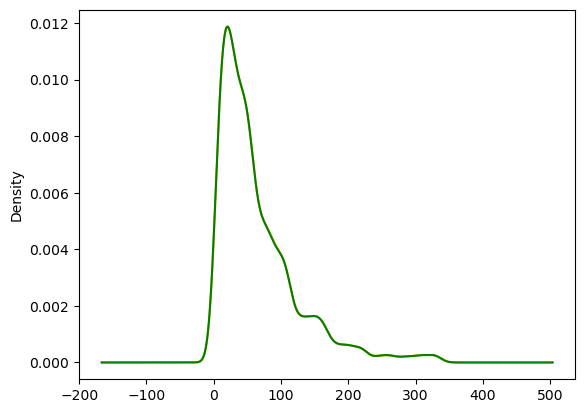

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='orange')

# data after cca
new_df['training_hours'].plot.density(color='green')

plt.show()

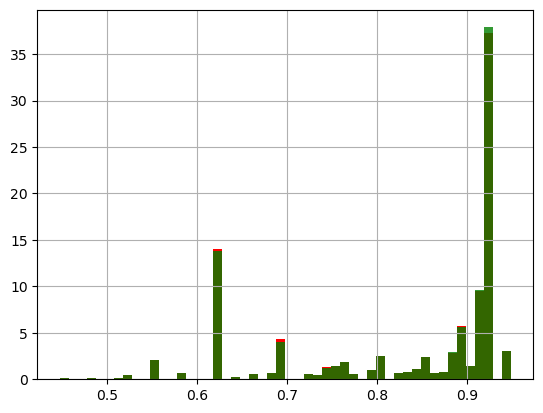

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original data
df['city_development_index'].hist(bins=50, density=True, color = 'red', ax=ax)


# New data
new_df['city_development_index'].hist(bins=50, density=True, color='green', ax=ax, alpha = 0.8)

plt.show()

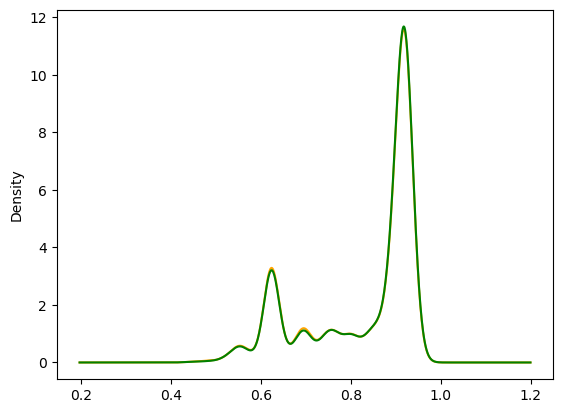

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original data
df['city_development_index'].plot.density(color='orange')

# New data
new_df['city_development_index'].plot.density(color='green')

plt.show()

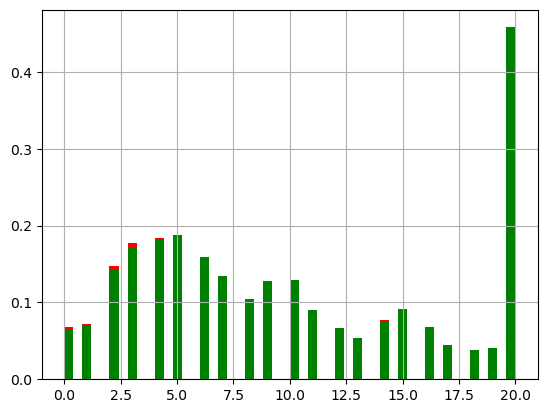

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original data
df['experience'].hist(bins=50, density=True, color='red', ax=ax)

new_df['experience'].hist(bins=50, density=True, color='green', ax=ax)

plt.show()

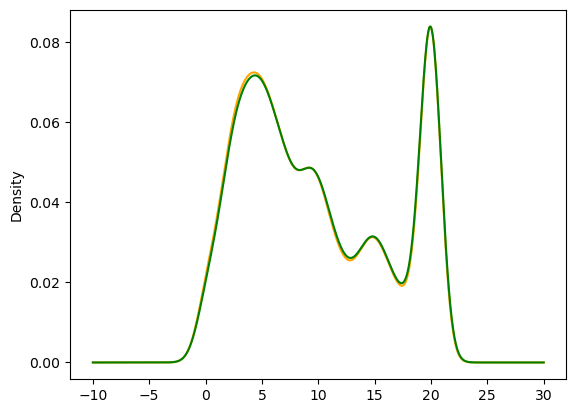

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].plot.density(color='orange')
new_df['experience'].plot.density(color='green')

plt.show()

In [20]:
temp = pd.concat([df['enrolled_university'].value_counts()/len(df), new_df['enrolled_university'].value_counts()/len(new_df)], axis = 1)

temp.columns = ['Original','CCA']
temp

,Original,CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [21]:
temp = pd.concat([df['education_level'].value_counts()/len(df), new_df['education_level'].value_counts()/len(new_df)], axis = 1)

temp.columns = ['Original','CCA']
temp

,Original,CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


## Mean/Median Imputation

Mean/median imputation is a simple data-cleaning technique used to fill missing numeric values (NaNs) by replacing them with the column’s central tendency—either the mean or the median—so you don’t have to drop rows with missing data. 

***

## Mean vs. Median: When to Use Which?

| Imputation Method | Best Used For                              | Distribution Shape       | Outlier Friendly?                                         |
|-------------------|---------------------------------------------|---------------------------|----------------------------------------------------------|
| **Mean**          | Symmetric, bell-shaped data (e.g., heights) | Normal / Symmetrical      | **No** – outliers pull the mean away from the true center |
| **Median**        | Skewed data (e.g., house prices, salaries)  | Skewed / Asymmetric       | **Yes** – extreme outliers don’t affect the middle value  |

***

## Advantages and Disadvantages

### Pros 👍

- **Very simple**: Easy to understand, explain, and calculate.  
- **Blazing fast**: Requires almost no computational power, even on large datasets.  
- **Keeps data size intact**: You retain all rows for modeling instead of deleting them. 

### Cons 👎

- **Shrinks variance**: Repeatedly inserting the same value makes the data appear less varied than it truly is.   
- **Disrupts relationships**: Ignores correlations between columns, potentially misleading models and distorting visualizations.   
- **Risky for discrete variables**: Can produce nonsensical values (e.g., 2.3 children per household) when applied to count or categorical-like numeric data.

### Using Pandas fillna()

In [22]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [24]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [25]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [26]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
print(X_train.shape)
print(y_train.shape)
print()
print(X_test.shape)
print(y_test.shape)

(712, 3)
(712,)

(179, 3)
(179,)


In [28]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [29]:
X_test.isnull().mean()

Age       0.206704
Fare      0.050279
Family    0.000000
dtype: float64

In [30]:
# Fill the missing values with mean/median
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [31]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [32]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
364,NaN,15.5000,1,29.498846,28.0,15.500000,15.5000
143,19.0,6.7500,0,19.000000,19.0,6.750000,6.7500
406,51.0,7.7500,0,51.000000,51.0,7.750000,7.7500
418,30.0,NaN,0,30.000000,30.0,32.517788,14.4000
329,16.0,57.9792,1,16.000000,16.0,57.979200,57.9792


In [33]:
print(f'Original Age variable variance {X_train['Age'].var()}')
print(f'Age variance after mean imputation {X_train['Age_mean'].var()}')
print(f'Age variance afte median imputation {X_train['Age_median'].var()}')
print()

print(f'Original Fare variable variance {X_train['Fare'].var()}')
print(f'Fare variance after mean imputation {X_train['Fare_mean'].var()}')
print(f'Fare variance afte median imputation {X_train['Fare_median'].var()}')

Original Age variable variance 210.2517072477438
Age variance after mean imputation 168.8519336687225
Age variance afte median imputation 169.20731007048096

Original Fare variable variance 2761.031434948639
Fare variance after mean imputation 2621.2323749512393
Fare variance afte median imputation 2637.01248167777


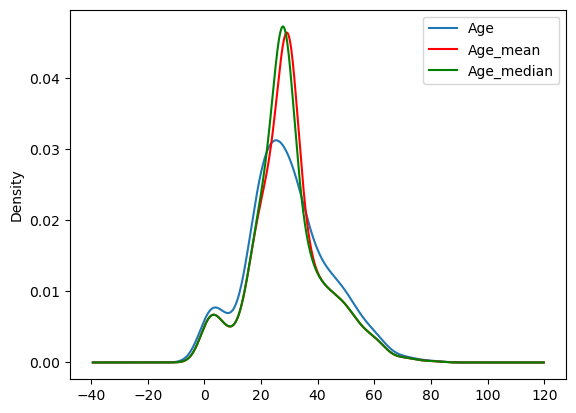

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Age'].plot(kind = 'kde', ax=ax)

# After mean/median imputaion
X_train['Age_mean'].plot(kind='kde', color='red',ax=ax)
X_train['Age_median'].plot(kind='kde', color='green',ax=ax)

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

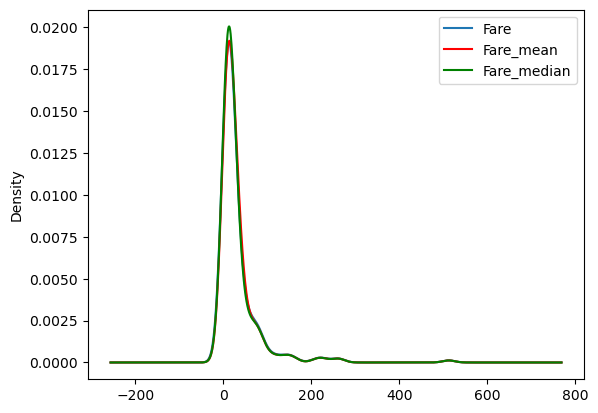

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# After mean/median imputation
X_train['Fare_mean'].plot(kind='kde',color='red',ax=ax)
X_train['Fare_median'].plot(kind='kde',color='green',ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

In [36]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [37]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

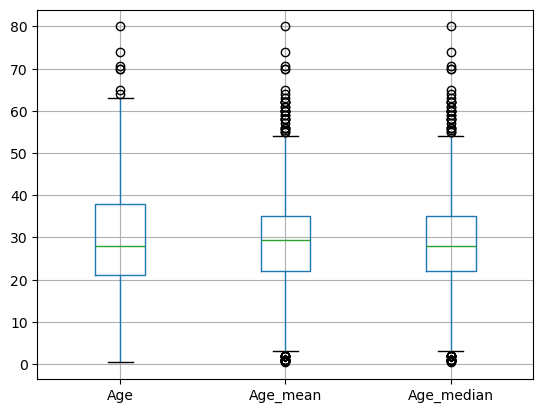

In [38]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

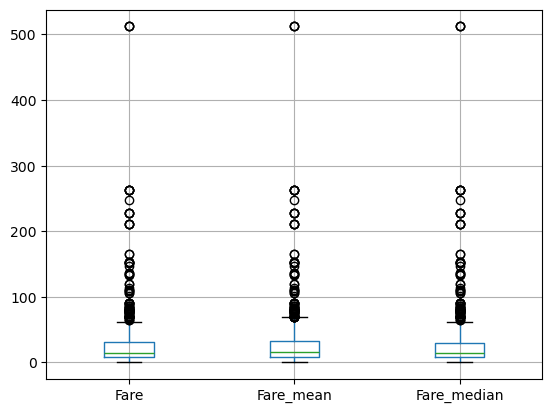

In [39]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

### Using Sklearn

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [41]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

transformer = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

transformer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(), ['Age']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [42]:
X_test.columns

Index(['Age', 'Fare', 'Family'], dtype='object')

In [43]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [44]:
transformer.named_transformers_.imputer1.statistics_

array([29.78590426])

In [45]:
transformer.named_transformers_.imputer2.statistics_

array([14.4583])

In [46]:
X_test_transformed

,imputer1__Age,imputer2__Fare,remainder__Family
707,42.000000,26.2875,0
37,21.000000,8.0500,0
615,24.000000,65.0000,3
169,28.000000,56.4958,0
68,17.000000,7.9250,6
...,...,...,...
89,24.000000,8.0500,0
80,22.000000,9.0000,0
846,29.785904,69.5500,10
870,26.000000,7.8958,0


## Arbitrary Value Imputation

Arbitrary value imputation is a data-cleaning technique where all missing values (NaNs) in a column are replaced with a specific, pre-determined number or string. 

The main idea is to **flag** missingness by using a value that lies completely outside the normal range of the data, so the model can recognize that these entries were originally missing instead of blending them with typical values. 

***

## 🛠️ Common Values Used

- **For positive-only numeric features**: `-1` (since real values can’t be negative).  
- **For general numeric features**: Out-of-range values like `99`, `999`, or `-999`.  
- **For categorical/text features**: New labels such as `"Missing"` or `"Unknown"` to create an explicit “missing” category. 

***

## 📊 When Should You Use It?

- **Missing Not At Random (MNAR)**  
  Use when the *fact* that data is missing is itself informative.  
  Example: High-income respondents refuse to report salary; encoding them as `-1` keeps this group together and preserves the “missingness” signal. 

- **Tree-based models**  
  Works well with algorithms like Decision Trees, Random Forests, and Gradient Boosting. These models can easily split on your flag (e.g., “Is age < 0?”) and treat the missing group separately. 

***

## ⚖️ Pros and Cons

| Advantages 🟢                                      | Disadvantages 🔴                                                    |
|----------------------------------------------------|---------------------------------------------------------------------|
| Super fast and easy to implement.                  | Distorts the data distribution by creating large spikes at the flag value. |
| Preserves the entire dataset; no rows are deleted. | Can break linear models (e.g., Linear/Logistic Regression) because the artificial values distort relationships. |
| Acts as a clear flag so models can learn patterns in missingness. | May introduce bias if the arbitrary value is not truly “out of range” or if assumptions about MNAR are wrong. |

If you want, I can also show a short Python/pandas snippet demonstrating how to apply arbitrary value imputation in practice.

In [47]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [49]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [50]:
X=df.drop(columns=['Survived'])
y=df['Survived']


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_minus1']=X_train['Age'].fillna(-1)

X_train['Fare_999']=X_train['Fare'].fillna(999)
X_train['Fare_minus1']=X_train['Fare'].fillna(-1)

In [52]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())
print()
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  210.2517072477438
Age Variance after 99 wala imputation:  932.9665366701436
Age Variance after -1 wala imputation:  315.99550362600644

Original Fare variable variance:  2761.031434948639
Fare Variance after 999 wala imputation:  47525.47059536007
Fare Variance after -1 wala imputation:  2675.2394049177087


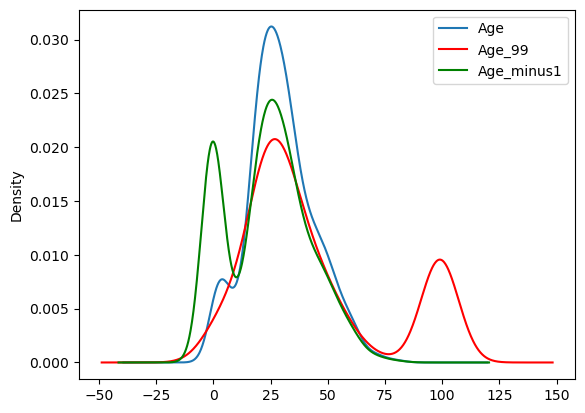

In [53]:
fig = plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax)

X_train['Age_99'].plot(kind='kde',color='red',ax=ax)
X_train['Age_minus1'].plot(kind='kde',color='green',ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

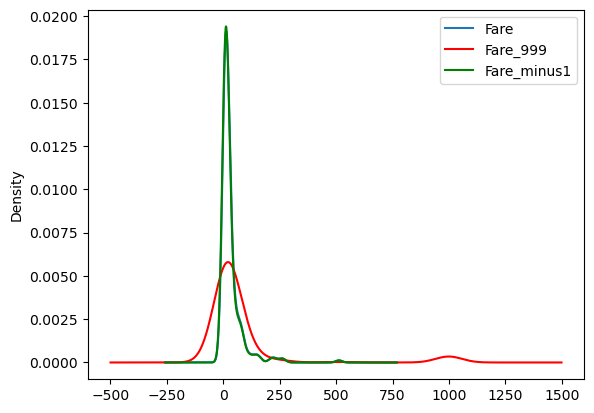

In [54]:
fig = plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)

X_train['Fare_999'].plot(kind='kde',color='red',ax=ax)
X_train['Fare_minus1'].plot(kind='kde',color='green',ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

In [55]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,130.495777,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,16.878492,17.684447
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-255.051165,-101.137070
Age_minus1,210.251707,135.785804,-5.034556,-166.460682,315.995504,262.712284,124.270305
Fare_999,130.495777,2761.031435,16.878492,-255.051165,262.712284,47525.470595,1063.944817
Fare_minus1,69.137162,2761.031435,17.684447,-101.137070,124.270305,1063.944817,2675.239405


In [56]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.039967,0.085422
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.046016,0.203212
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.038303,-0.064017
Age_minus1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.067792,0.135159
Fare_999,0.039967,1.000000,0.046016,-0.038303,0.067792,1.000000,0.094357
Fare_minus1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.094357,1.000000


<Axes: >

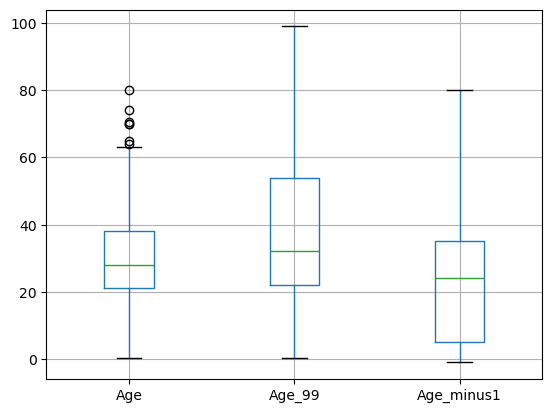

In [57]:
X_train[['Age','Age_99','Age_minus1']].boxplot()

<Axes: >

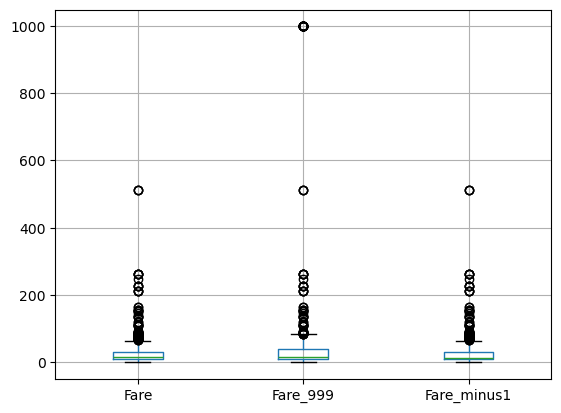

In [58]:
X_train[['Fare','Fare_999','Fare_minus1']].boxplot()

### Using Sklearn

In [59]:
X=df.drop(columns=['Survived'])
y=df['Survived']
X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
transformer = ColumnTransformer([
    ('imputer1', SimpleImputer(strategy='constant', fill_value=99),['Age']),
    ('imputer2', SimpleImputer(strategy='constant', fill_value=999),['Fare'])
], remainder='passthrough')

transformer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [61]:
X_train_transformed=transformer.fit_transform(X_train)
X_test_transformed=transformer.transform(X_test)

In [62]:
transformer.named_transformers_.imputer1.statistics_

array([99.])

In [63]:
transformer.named_transformers_.imputer2.statistics_

array([999.])

In [64]:
X_train_transformed

,imputer1__Age,imputer2__Fare,remainder__Family
709,99.0,15.2458,2
439,31.0,10.5000,0
840,20.0,7.9250,0
720,6.0,33.0000,1
39,14.0,11.2417,1
...,...,...,...
433,17.0,7.1250,0
773,99.0,7.2250,0
25,38.0,31.3875,6
84,17.0,10.5000,0


## End-of-Distribution Imputation

End-of-distribution imputation is an automated technique that replaces missing values with a number placed at the extreme edge of a feature’s distribution—either far above the maximum (right tail) or far below the minimum (left tail). 

Instead of manually picking arbitrary values like `-1` or `999`, this method uses statistics to compute a flag value that lies clearly outside the normal range of observed data. 

***

## 🧮 How to Find the “End of Distribution” Value

The formula depends on the shape of the distribution.

### 1. For Normally Distributed Data (Bell Curve)

Use the **mean** and **standard deviation (σ)**, typically moving **3 standard deviations** away from the mean:

- **Right tail**:  
  upper_value = mu + 3*sigma
 
- **Left tail**:  
 lower_value = mu - 3*sigma
  

where `mu` is the mean and `sigma` is the standard deviation. 

### 2. For Skewed Data (Asymmetrical Distribution)

Use the **interquartile range (IQR)**, which is more robust to outliers:

- Compute:
  - Q_1: 25th percentile  
  - Q_3: 75th percentile  
  - IQR = Q_3 - Q_1

- **Right tail**:  
  upper_value = Q_3 + 3*IQR
  
- **Left tail**:  
  lower_value = Q_1 - 3*IQR
  

This places the imputed value well beyond the bulk of the data while respecting skewness. 

***

## 📊 When Should You Use It?

- **Missing Not At Random (MNAR)**  
  Use when the fact that a value is missing carries information you want the model to learn (e.g., high-income individuals not reporting salary). The extreme flag preserves that “missingness” signal. 

- **Tree-Based Models**  
  Works well with Decision Trees, Random Forests, and Gradient Boosting, which can easily split on the flag (e.g., “Is value > right-tail threshold?”) and treat missing entries as a separate group. 

- **Automated Pipelines**  
  Preferable to arbitrary imputation in automated workflows because the flag value is computed directly from the data, removing the need for manual inspection and tuning. 

***

## ⚖️ Pros and Cons

| Advantages 🟢                                                | Disadvantages 🔴                                                                 |
|--------------------------------------------------------------|----------------------------------------------------------------------------------|
| No manual guessing; the data itself determines the flag value. | Alters the distribution by creating a large artificial spike at the tail.        |
| Clear separation between real values and the missing-data flag. | Can harm linear models (e.g., Linear/Logistic Regression) by distorting fits.    |
| Preserves all rows; no data is dropped.                      | If future real data extends even further out, the boundary between real and flag can blur. |

If you’d like, I can next show a concise Python example that computes these end-of-distribution values and applies them to a DataFrame.

In [65]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


<Axes: ylabel='Density'>

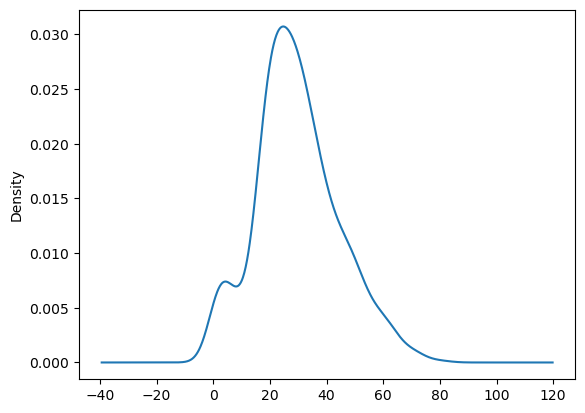

In [66]:
df['Age'].plot(kind='kde')

<Axes: ylabel='Density'>

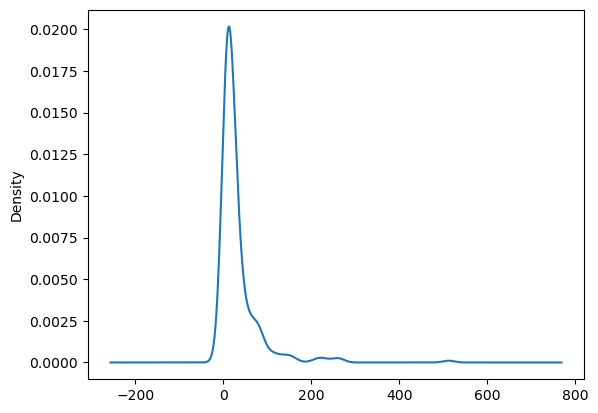

In [67]:
df['Fare'].plot(kind='kde')

In [68]:
age_mu = df['Age'].mean()
age_std = df['Age'].std()

In [69]:
age_mu, age_std

(np.float64(29.69911764705882), 14.526497332334044)

In [70]:
age_eod = age_mu + 3*age_std
age_eod

np.float64(73.27860964406095)

In [71]:
fare_q1 = df['Fare'].quantile(0.25)
fare_q3=df['Fare'].quantile(0.75)

iqr=fare_q3 - fare_q1

fare_eod = fare_q3 + 3*iqr
fare_eod

np.float64(101.13759999999998)

In [72]:
X=df.drop(columns=['Survived'])
y=df['Survived']

X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
transformer = ColumnTransformer([
    ('imputer1', SimpleImputer(strategy='constant', fill_value=age_eod),['Age']),
    ('imputer2', SimpleImputer(strategy='constant', fill_value=fare_eod),['Fare'])
], remainder='passthrough')

transformer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=np.float64(73.27860964406095),
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=np.float64(101.13759999999998),
                                               strategy='constant'),
                                 ['Fare'])])

In [74]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed=transformer.transform(X_test)

In [75]:
transformer.named_transformers_.imputer1.statistics_

array([73.27860964])

In [76]:
transformer.named_transformers_.imputer2.statistics_

array([101.1376])

In [77]:
X_train_transformed

,imputer1__Age,imputer2__Fare,remainder__Family
709,73.27861,15.2458,2
439,31.00000,10.5000,0
840,20.00000,7.9250,0
720,6.00000,33.0000,1
39,14.00000,11.2417,1
...,...,...,...
433,17.00000,7.1250,0
773,73.27861,7.2250,0
25,38.00000,31.3875,6
84,17.00000,10.5000,0


In [78]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [80]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [81]:
X=df.drop(columns=['Survived'])
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [82]:
X_train['Age_eod']=X_train['Age'].fillna(age_eod)
X_train['Fare_eod']=X_train['Fare'].fillna(fare_eod)

In [83]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after eod imputation: ', X_train['Age_eod'].var())
print()
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after eod imputation: ', X_train['Fare_eod'].var())

Original Age variable variance:  210.2517072477438
Age Variance after eod imputation:  472.0464150844214

Original Fare variable variance:  2761.031434948639
Fare Variance after eod imputation:  2847.5918372373776


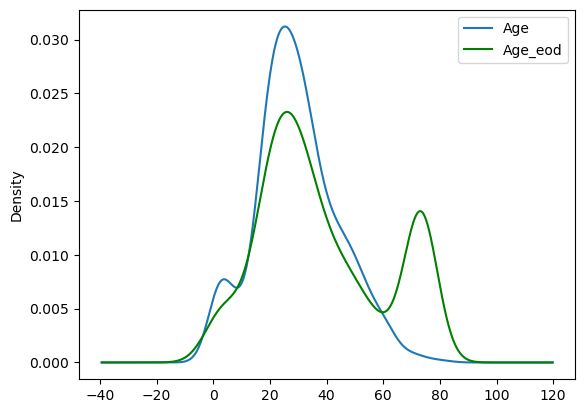

In [84]:
fig = plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax)
X_train['Age_eod'].plot(kind='kde',color='green',ax=ax)

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

plt.show()

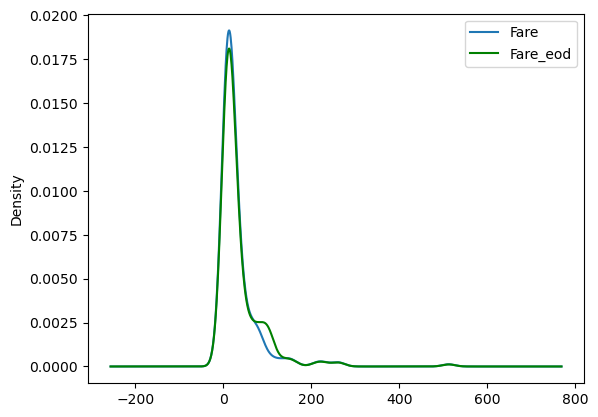

In [85]:
fig = plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)
X_train['Fare_eod'].plot(kind='kde',color='green',ax=ax)

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

plt.show()

In [86]:
X_train.cov()

,Age,Fare,Family,Age_eod,Fare_eod
Age,210.251707,75.481375,-6.993325,210.251707,75.404184
Fare,75.481375,2761.031435,18.599163,-48.240083,2761.031435
Family,-6.993325,18.599163,2.830892,-6.451366,17.602129
Age_eod,210.251707,-48.240083,-6.451366,472.046415,-51.199027
Fare_eod,75.404184,2761.031435,17.602129,-51.199027,2847.591837


In [87]:
X_train.corr()

,Age,Fare,Family,Age_eod,Fare_eod
Age,1.000000,0.091482,-0.319651,1.000000,0.090977
Fare,0.091482,1.000000,0.207193,-0.042047,1.000000
Family,-0.319651,0.207193,1.000000,-0.176481,0.196049
Age_eod,1.000000,-0.042047,-0.176481,1.000000,-0.044160
Fare_eod,0.090977,1.000000,0.196049,-0.044160,1.000000


<Axes: >

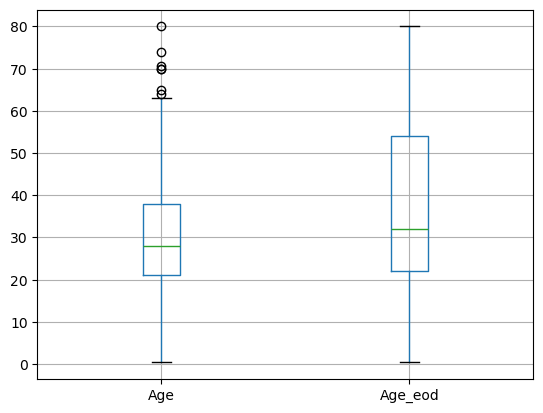

In [88]:
X_train[['Age','Age_eod']].boxplot()

<Axes: >

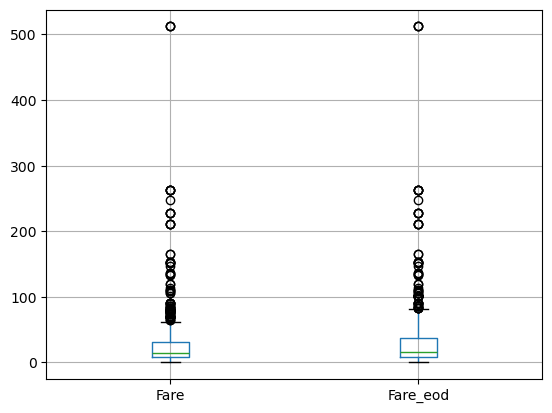

In [89]:
X_train[['Fare','Fare_eod']].boxplot()

### Handling Categorical Values - Frequent Value Imputation

In [91]:
df = pd.read_csv('train2.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [93]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

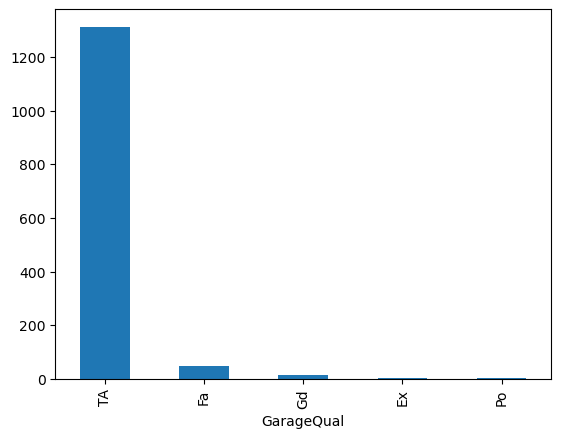

In [95]:
df['GarageQual'].value_counts().plot(kind='bar')

In [96]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

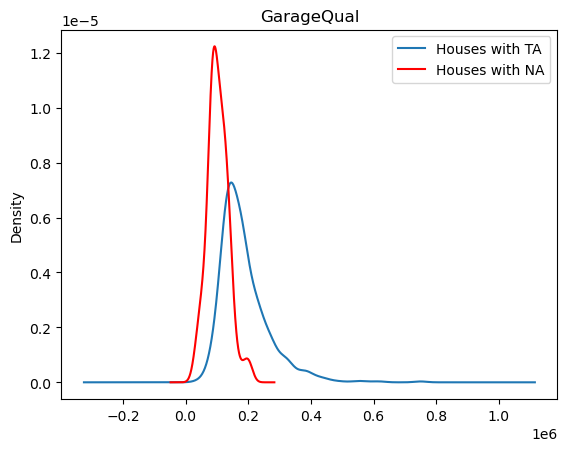

In [102]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')
plt.show()

In [103]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']
temp

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1311, dtype: int64

In [104]:
df['GarageQual'].fillna('TA', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_26840\1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

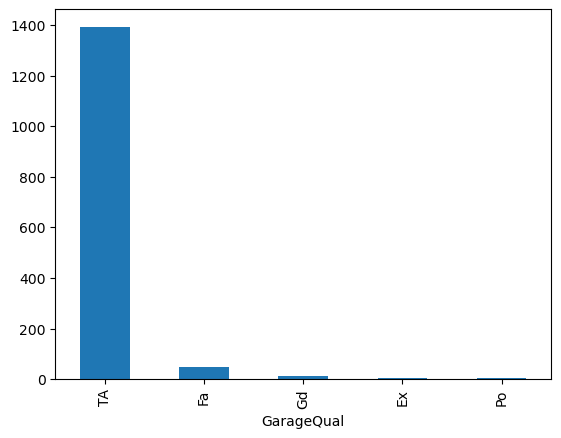

In [105]:
df['GarageQual'].value_counts().plot(kind='bar')

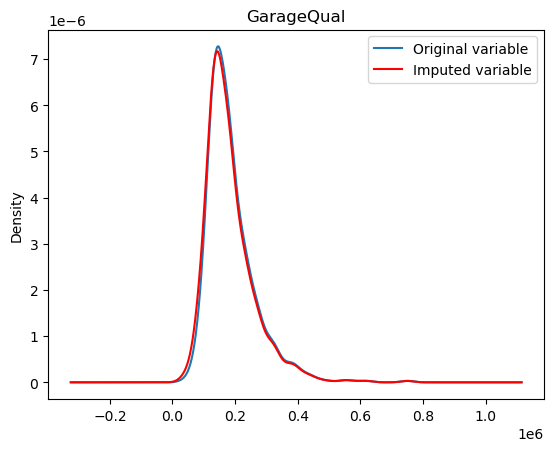

In [108]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')
plt.show()

<Axes: xlabel='FireplaceQu'>

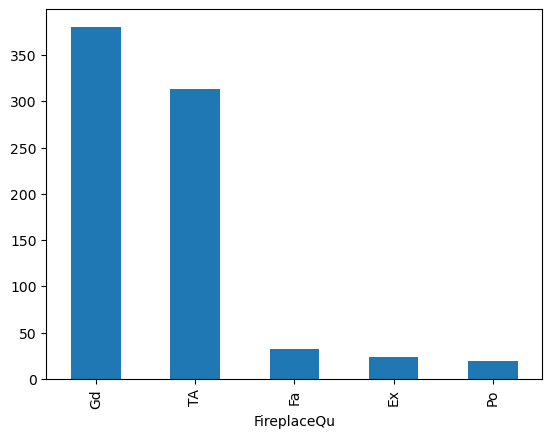

In [111]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [112]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

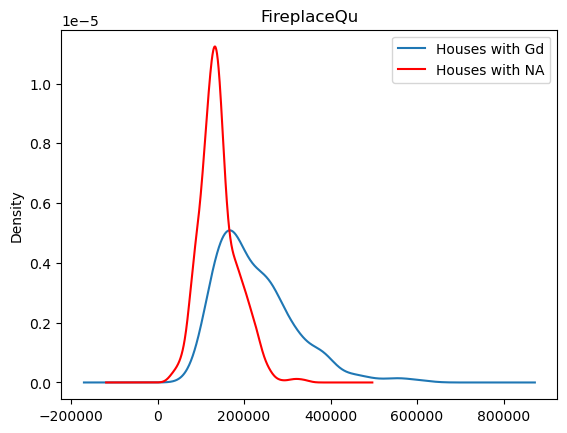

In [114]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

plt.show()

In [115]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [116]:
df['FireplaceQu'].fillna('Gd', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_26840\3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

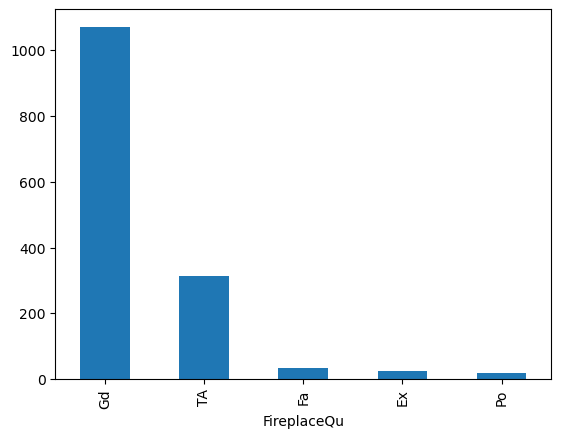

In [117]:
df['FireplaceQu'].value_counts().plot(kind='bar')

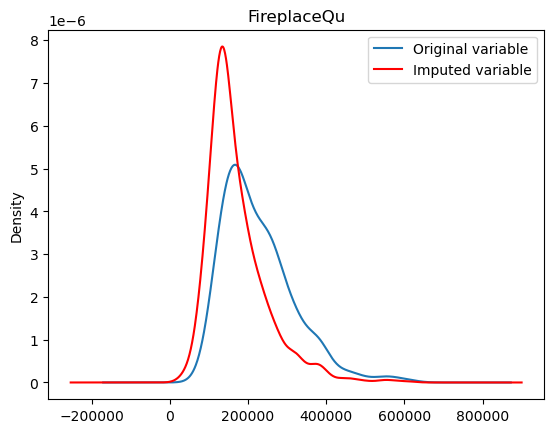

In [118]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,lables = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']

ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

plt.show()

### Using Sklearn

In [119]:
X=df.drop(columns=['SalePrice'])
y=df['SalePrice']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [120]:
imputer = SimpleImputer(strategy='most_frequent')
imputer.set_output(transform='pandas')

SimpleImputer(strategy='most_frequent')

In [121]:
X_train_transformed = imputer.fit_transform(X_train)
X_test_transformed = imputer.transform(X_test)

In [123]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

### Missing Category Imputation

In [124]:
df = pd.read_csv('train2.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [125]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

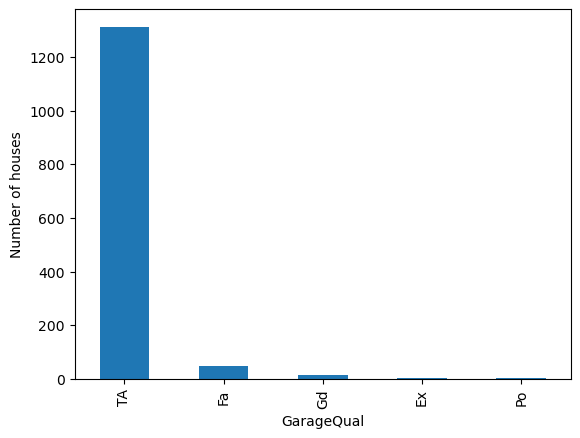

In [128]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

plt.show()

In [129]:
df['GarageQual'].fillna('Missing', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_26840\4070582888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('Missing', inplace=True)


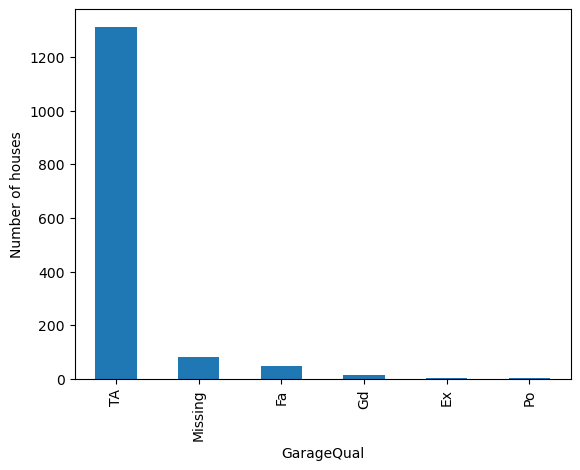

In [130]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

plt.show()

### Using Sklearn

In [131]:
X=df.drop(columns='SalePrice')
y=df['SalePrice']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [132]:
imputer = SimpleImputer(strategy='constant', fill_value='Missing')
imputer.set_output(transform='pandas')

SimpleImputer(fill_value='Missing', strategy='constant')

In [134]:
X_train_transformed = imputer.fit_transform(X_train)
X_test_transformed = imputer.transform(X_test)

In [136]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)